In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

In [2]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2))

gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw(),gen], target_record=target_record)
benchmarking_metric = AUCMetric([0, 0.17, 0.33, 0.5, 0.67, 0.83])


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
# pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric)

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")

In [ ]:
pipeline.ml_utility("income")

Evaluating original data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : Raw
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Evaluating : PrivBayes_epsilon=1.0
Evaluating generated data
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Results saved to results_ml_utility.csv


In [ ]:
pipeline.average_dcr(100,metric="gower")

Evaluating : Raw
Evaluating : PrivBayes_epsilon=1.0


0.1878973

In [7]:
results = pipeline.data_results()

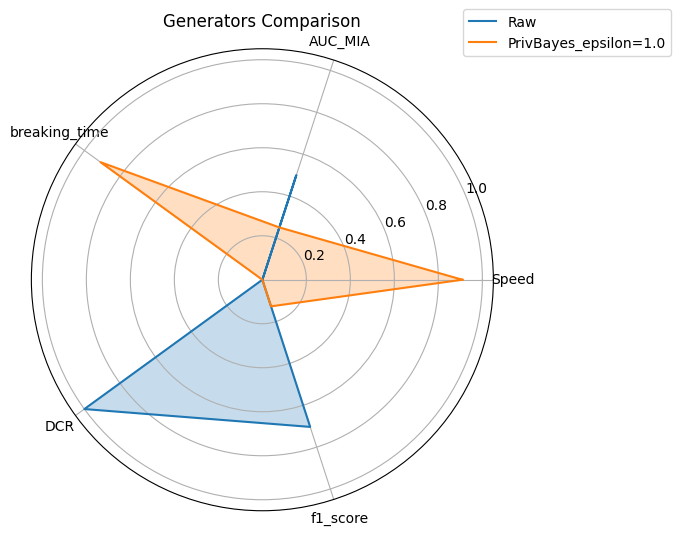

In [10]:

import matplotlib.pyplot as plt
import numpy as np

# metrics and angles setup as before
metrics = ['Speed', 'AUC_MIA', 'breaking_time', 'DCR', 'f1_score']
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# build figure a bit wider
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'polar': True})

# plot each model
for _, row in results.iterrows():
    vals = [row[m] for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, label=row['Model'])
    ax.fill(angles, vals, alpha=0.25)

# labels & title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title('Generators Comparison')

# give extra room on the right for the legend
fig.subplots_adjust(right=0.75)

# push the legend further out
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))

plt.show()

In [ ]:
data = tapas.datasets.TabularDataset.read("data/dummy")
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,2,2))

#gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw()], target_record=target_record)
benchmarking_metric = AUCMetric([0, 0.17, 0.33, 0.5, 0.67, 0.83])

# Function to close the loop for radar chart
def radar_data(data):
    return data + [data[0]]

# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric)

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")

[2 1 0]


1